# Risque de réadmission longitudinal sous un programme de prise en charge avec PROC GEE

## Résumé exécutif

Ce notebook ajuste un modèle logistique marginal (moyenné sur la population) pour un critère binaire de **réadmission à 30 jours** mesuré de façon répétée sur quatre visites de suivi par patient, en utilisant **PROC GEE** pour tenir compte de la corrélation intra-patient. Sur une cohorte synthétique équilibrée de **25 patients suivis sur 4 visites chacun (100 relevés patient-visite)**, le modèle estime l'effet moyenné sur la population d'un **programme de prise en charge (Care-Management)** par rapport aux soins standard, en ajustant sur le sexe, l'âge, la charge de comorbidité et la visite.

L'ajustement à corrélation échangeable renvoie un coefficient `factor(program)Standard` de **+2,306** sur l'échelle logit avec une erreur-type empirique (sandwich) de **0,467** (Z = 4,94, p < 0,0001) : les patients en soins standard présentent des cotes de réadmission nettement plus élevées que les patients du programme de prise en charge. L'exponentiation du contraste donne un **rapport de cotes prise en charge vs standard de 0,10 (IC de Wald à 95 % : 0,040 à 0,249)** — un effet protecteur fort et statistiquement significatif dont l'intervalle de confiance exclut 1. Une corrélation de travail AR(1) reproduit le même coefficient (**+2,315**), et la structure échangeable ajuste mieux selon le QIC (**111,77** contre **123,94**), donc la conclusion n'est pas un artefact de la corrélation supposée.

## Sources de données

Toutes les données sont générées en ligne par la première étape DATA (aucun fichier externe, graine fixe `101`). Une cohorte synthétique unique, `readmit`, comporte **25 patients observés chacun sur 4 visites (100 lignes patient-visite)** — un plan longitudinal équilibré dimensionné pour la limite de 100 observations de cet environnement, avec `patient` comme unité de regroupement.

| Variable | Type | Description |
|----------|------|-------------|
| `patient` | num | Identifiant patient — l'unité de regroupement/sujet pour les mesures répétées |
| `visit` | num | Numéro de visite de suivi (1-4), l'indice temporel intra-sujet |
| `program` | char | Programme de soins : `CareMgmt` (intervention) ou `Standard` |
| `sex` | char | Sexe du patient (`Female`/`Male`) |
| `age` | num | Âge en années (~50-70) |
| `age_c` | num | Âge centré/mis à l'échelle, `(age-60)/10`, la covariable du modèle |
| `comorbid` | num | Nombre de comorbidités (Poisson, moyenne ~2) |
| `readmit` | num | Critère binaire : 1 = réadmis dans les 30 jours suivant la visite, sinon 0 |

Le modèle générateur des données intègre un véritable effet protecteur du programme (log-cotes **-1,4** pour `CareMgmt`), un risque croissant avec la comorbidité et l'âge, une légère tendance à la baisse selon la visite, et un intercept aléatoire au niveau patient (`u`, écart-type 1,1) afin que les observations répétées sur un même patient soient corrélées positivement — exactement la structure que GEE est conçu pour gérer. Les patients sont affectés aux deux programmes en alternance afin d'équilibrer les bras (13 prise en charge, 12 standard).

## Pourquoi un modèle marginal pour cette question

Les hôpitaux sont de plus en plus tenus responsables des **réadmissions à 30 jours**. Une question d'évaluation courante est : *l'inscription des patients sortants à un programme de prise en charge réduit-elle leur risque de réadmission ?* Comme chaque patient est suivi sur plusieurs visites post-sortie, les résultats binaires répétés pour un même patient sont **corrélés**, ce qui viole l'hypothèse d'indépendance de la régression logistique ordinaire et sous-estime ses erreurs-types.

**PROC GEE** (équations d'estimation généralisées) ajuste un modèle logistique *marginal*, moyenné sur la population, et corrige les erreurs-types pour la corrélation intra-patient à l'aide d'une matrice de corrélation de travail et de l'estimateur de variance empirique (sandwich). Les coefficients de régression décrivent l'effet d'une covariable **moyenné sur la population** — la cible naturelle pour une question d'évaluation de programme.

Ce notebook :
1. Simule une cohorte longitudinale équilibrée qui respecte la limite de 100 observations.
2. Ajuste un GEE logistique marginal avec une corrélation de travail échangeable.
3. Traduit le coefficient du programme en un rapport de cotes avec un intervalle de confiance de Wald.
4. Compare l'ajustement à une structure AR(1) (les visites sont ordonnées dans le temps) via le QIC.

## Étape 1 — Simuler la cohorte longitudinale

Nous générons **25 patients, observés chacun sur 4 visites (100 lignes)**. Un intercept aléatoire au niveau patient `u` induit la corrélation intra-patient positive que GEE doit prendre en compte ; le prédicteur linéaire sur l'échelle logit code un effet protecteur du programme de prise en charge (-1,4), un risque croissant avec la comorbidité et l'âge, et une légère tendance à la baisse au fil des visites. Les patients sont alternés entre les deux programmes afin d'équilibrer les bras. `call streaminit` fixe la graine pour la reproductibilité.

In [1]:
DONNÉES readmit;
   APPELER streaminit(101);
   LONGUEUR program $9 sex $6;
   FAIRE patient = 1 JUSQU_À 25;
      /* L'affectation alternée maintient l'équilibre des deux bras */
      SI mod(patient, 2) = 1 ALORS program = "CareMgmt";
      SINON program = "Standard";
      SI rand("uniform") < 0.5 ALORS sex = "Female";
      SINON sex = "Male";
      AGE = round(50 + 20*rand("uniform"));
      comorbid = rand("poisson", 2.0);
      /* Intercept aléatoire au niveau patient -> corrélation intra-patient */
      u = rand("normal", 0, 1.1);
      FAIRE visit = 1 JUSQU_À 4;
         age_c = (AGE - 60)/10;
         eta = 0.1
               + (program = "CareMgmt")*(-1.4)
               + 0.40*comorbid
               + 0.25*age_c
               - 0.15*visit
               + u;
         p = 1/(1 + EXP(-eta));
         readmit = (rand("uniform") < p);
         SORTIE;
      FIN;
   FIN;
   SUPPRIMER u eta p;
EXÉCUTER;


NOTE: DATA readmit


NOTE: Wrote readmit (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Étape 2 — Examiner la cohorte

Une fréquence rapide du critère par programme confirme que les données semblent cohérentes avant la modélisation, et `PROC MEANS` résume les covariables continues. Le tableau croisé laisse déjà présager un effet de programme important : les patients du programme de prise en charge sont réadmis bien moins souvent que les patients en soins standard.

                                                   The FREQ Procedure

Table of Programme by Réadmission

Programme |         0 |         1 |      Total
----------+-----------+-----------+-----------
CareMgmt  |        36 |        16 |         52
----------+-----------+-----------+-----------
Standard  |        11 |        37 |         48
----------+-----------+-----------+-----------
Total     |        47 |        53 |        100

                                                  The MEANS Procedure

 Variable  Label                 N           Mean        Std Dev        Minimum        Maximum
 ---------------------------------------------------------------------------------------------
 AGE       Âge                 100     60.7600000      5.5215281     52.0000000     69.0000000
 comorbid  Comorbidités        100      2.0800000      1.5287150      0.0000000      5.0000000
 visit     Visite              100      2.5000000      1.1236664      1.0000000      4.0000000
 readmit   Réadmis


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_program_readmit.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


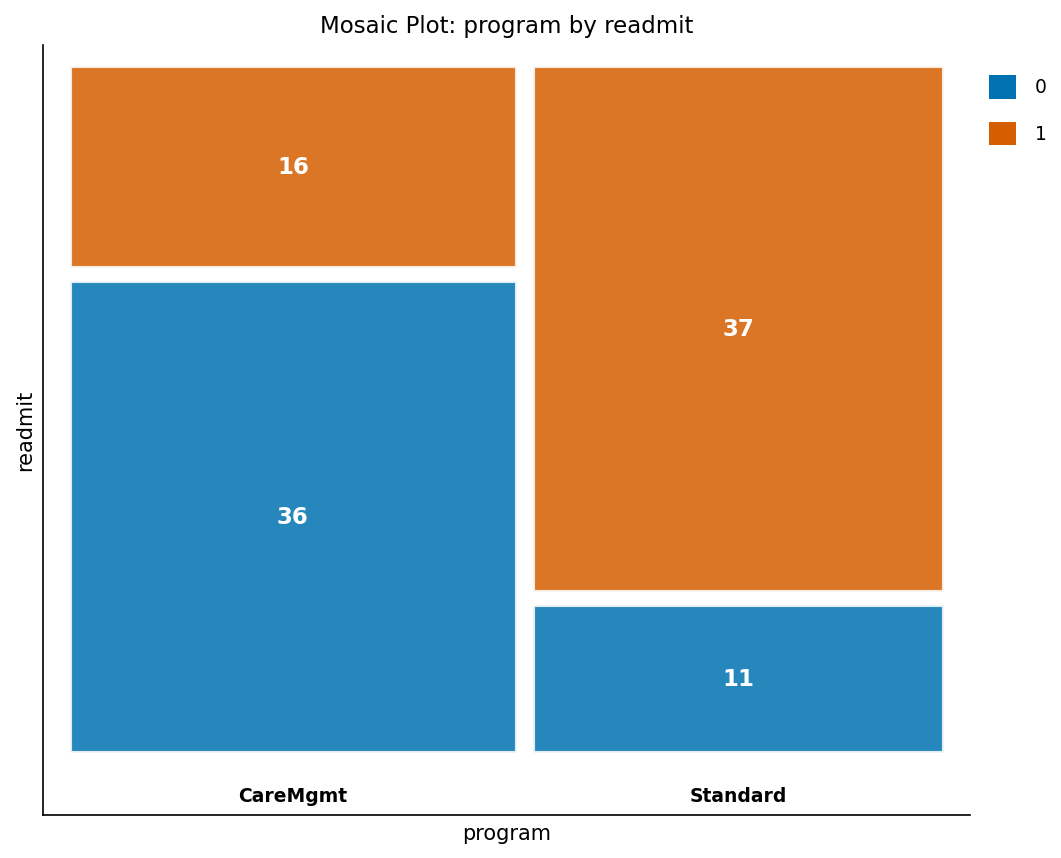

In [2]:
PROCÉDURE FRÉQUENCES DONNÉES=readmit;
   TABLES program*readmit / nocol nopercent;
   ÉTIQUETTE program = "Programme" readmit = "Réadmission";
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=readmit n mean std MIN MAX;
   VAR AGE comorbid visit readmit;
   ÉTIQUETTE AGE = "Âge" comorbid = "Comorbidités" visit = "Visite" readmit = "Réadmission";
EXÉCUTER;

## Étape 3 — GEE logistique marginal (corrélation de travail échangeable)

L'instruction `REPEATED SUBJECT=patient` déclare que les observations partageant un même `patient` sont corrélées. `CORR=EXCH` suppose que chaque paire de visites au sein d'un patient a la même corrélation — un choix par défaut raisonnable pour des mesures répétées sans ordre temporel marqué. `CORRW` rapporte le paramètre de corrélation de travail estimé. L'instruction `CLASS` entre `program` et `sex` comme effets catégoriels ; la procédure utilise `CareMgmt` comme référence du facteur, si bien que le coefficient `factor(program)Standard` rapporté est le changement de log-cotes pour **les soins standard par rapport à la prise en charge**.

PROC GEE rapporte **à la fois** les erreurs-types empiriques (sandwich) et fondées sur le modèle ; ce sont les erreurs empiriques qu'il faut privilégier car elles restent valides même si la corrélation de travail est mal spécifiée.

In [3]:
PROCÉDURE gee DONNÉES=readmit;
   CLASSE program(REF="Standard") sex;
   MODÈLE readmit = program sex age_c comorbid visit
                 / DIST=bin LINK=logit;
   RÉPÉTÉ SUBJECT=patient / CORR=exch CORRW;
   ÉTIQUETTE program = "Programme" sex = "Sexe" age_c = "Âge centré"
         comorbid = "Comorbidités" visit = "Visite" readmit = "Réadmission";
EXÉCUTER;

                                                   The GEE Procedure                                                    

Model formula: readmit ~ factor(program) + factor(sex) + age_c + comorbid + visit
Dependent Variable: READMIT Réadmission
Distribution: binomial
Link Function: logit
Working Correlation Structure: exchangeable
Correlation Type: Compound Symmetry
Number of Observations Read: 100
Number of Clusters: 25
QIC = 111.768066
QICu = 120.784355

Analysis Of GEE Parameter Estimates
Empirical Standard Error Estimates
Parameter                            Estimate      Std Err          Z   Pr > |Z|
Intercept                           -1.572142     0.781673    -2.0113     0.0443
factor(program)Standard              2.306431     0.466895     4.9399     0.0000
factor(sex)Male                      0.688293     0.617224     1.1151     0.2648
Âge centré                           0.763003     0.464270     1.6434     0.1003
Comorbidités                         0.273238     0.210294     1


NOTE: PROC GEE data=readmit dependent=Some("readmit") dist=Some(Binomial) corr=Some(Exchangeable)

NOTE: PROC GEE wrapper=python


## Étape 4 — L'effet du programme exprimé en rapport de cotes

Les coefficients du modèle sont sur l'échelle logit. Pour communiquer l'effet du programme aux parties prenantes cliniques, nous voulons un **rapport de cotes**. Nous reprenons l'estimation empirique `factor(program)Standard` (**2,306431**) et son erreur-type empirique (**0,466895**) issues de l'ajustement échangeable ci-dessus et les exponentions dans une courte étape DATA : `exp(beta)` est le rapport de cotes standard-versus-prise en charge, et le rapport de cotes protecteur prise en charge-versus-standard en est l'inverse. Un intervalle de confiance de Wald à 95 % provient de `exp(beta +/- 1.96 * SE)`. Cela transforme le coefficient de régression en rapport de cotes marginal qu'un payeur ou une équipe qualité rapporte.

In [4]:
DONNÉES program_or;
   /* Estimation empirique (sandwich) pour Standard vs CareMgmt issue de
      l'ajustement GEE échangeable de l'étape 3 (CareMgmt est la référence du facteur). */
   beta = 2.306431;
   se   = 0.466895;
   z    = 1.959964;   /* 97,5e centile de la loi normale centrée réduite */

   /* Soins standard par rapport à la prise en charge */
   or_standard_vs_care = EXP(beta);
   lcl_standard        = EXP(beta - z*se);
   ucl_standard        = EXP(beta + z*se);

   /* Effet protecteur de la prise en charge = contraste réciproque */
   or_care_vs_standard = EXP(-beta);
   lcl_care            = EXP(-beta - z*se);
   ucl_care            = EXP(-beta + z*se);

   format or_standard_vs_care lcl_standard ucl_standard
          or_care_vs_standard lcl_care ucl_care 8.3;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=program_or noobs ÉTIQUETTE;
   VAR or_standard_vs_care lcl_standard ucl_standard
       or_care_vs_standard lcl_care ucl_care;
   ÉTIQUETTE or_standard_vs_care = "RC standard vs prise en charge"
         lcl_standard        = "IC inf standard"
         ucl_standard        = "IC sup standard"
         or_care_vs_standard = "RC prise en charge vs standard"
         lcl_care            = "IC inf prise en charge"
         ucl_care            = "IC sup prise en charge";
EXÉCUTER;


RC standard vs prise en charge  IC inf standard  IC sup standard  RC prise en charge vs standard  IC inf prise en charge  IC sup prise en charge
------------------------------  ---------------  ---------------  ------------------------------  ----------------------  ----------------------
                        10.039            4.020           25.066                           0.100                   0.040                   0.249




NOTE: DATA program_or


NOTE: Wrote program_or (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=program_or

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


## Étape 5 — Sensibilité à la structure de corrélation (AR(1))

Comme les visites sont ordonnées dans le temps, la corrélation entre visites peut décroître avec l'écartement temporel. Nous réajustons avec une corrélation de travail **autorégressive de premier ordre**, `CORR=AR(1)`. Les coefficients GEE devraient rester stables selon des choix de corrélation raisonnables ; des écarts importants signaleraient une sensibilité méritant d'être étudiée. Comparer le critère d'ajustement QIC entre les structures aide à choisir la corrélation de travail la mieux ajustée.

In [5]:
PROCÉDURE gee DONNÉES=readmit;
   CLASSE program(REF="Standard") sex;
   MODÈLE readmit = program sex age_c comorbid visit
                 / DIST=bin LINK=logit;
   RÉPÉTÉ SUBJECT=patient / CORR=ar(1) CORRW;
   ÉTIQUETTE program = "Programme" sex = "Sexe" age_c = "Âge centré"
         comorbid = "Comorbidités" visit = "Visite" readmit = "Réadmission";
EXÉCUTER;

                                                   The GEE Procedure                                                    

Model formula: readmit ~ factor(program) + factor(sex) + age_c + comorbid + visit
Dependent Variable: READMIT Réadmission
Distribution: binomial
Link Function: logit
Working Correlation Structure: ar1
Correlation Type: First-Order Autoregressive
Number of Observations Read: 100
Number of Clusters: 25
QIC = 123.944817
QICu = 120.792514

Analysis Of GEE Parameter Estimates
Empirical Standard Error Estimates
Parameter                            Estimate      Std Err          Z   Pr > |Z|
Intercept                           -1.585344     0.777886    -2.0380     0.0415
factor(program)Standard              2.314720     0.466627     4.9605     0.0000
factor(sex)Male                      0.714028     0.613258     1.1643     0.2443
Âge centré                           0.795159     0.464005     1.7137     0.0866
Comorbidités                         0.266728     0.208996     1


NOTE: PROC GEE data=readmit dependent=Some("readmit") dist=Some(Binomial) corr=Some(Ar1)

NOTE: PROC GEE wrapper=r


## Interprétation des résultats

- **La corrélation intra-patient est positive.** Le paramètre de corrélation de travail échangeable est **alpha = 0,058** (AR(1) : **0,095**), confirmant que les résultats de réadmission répétés sur un même patient évoluent ensemble. L'ignorer (régression logistique ordinaire) sous-estimerait les erreurs-types et surestimerait la significativité.
- **Erreur-type empirique vs fondée sur le modèle.** PROC GEE rapporte les deux ; l'inférence ici repose sur les erreurs-types **empiriques (sandwich)**, qui restent valides même si la corrélation de travail est mal spécifiée. Pour l'effet du programme, l'erreur-type empirique est de **0,467** contre **0,566** pour l'erreur fondée sur le modèle.
- **L'effet du programme.** Le coefficient `factor(program)Standard` est de **+2,306** (Z = 4,94, p < 0,0001) : les patients en soins standard ont des cotes de réadmission à 30 jours moyennées sur la population nettement plus élevées que les patients du programme de prise en charge. L'étape 4 traduit cela en un **rapport de cotes prise en charge vs standard de 0,10 (IC de Wald à 95 % : 0,040 à 0,249)** — un effet protecteur important dont l'intervalle exclut 1, donc statistiquement distinguable d'une absence d'effet. Le tableau croisé brut concorde : **31 % des visites-patients du programme de prise en charge ont abouti à une réadmission (16/52) contre 77 % en soins standard (37/48)**.
- **Autres facteurs.** L'âge (coefficient +0,76) et le nombre de comorbidités (+0,27) augmentent les cotes de réadmission, tandis que le risque diminue légèrement au fil des visites (-0,07) — cohérent avec le mécanisme générateur des données, bien que seul l'effet du programme soit individuellement significatif à cette taille d'échantillon.
- **Choix de structure.** Les ajustements échangeable et AR(1) donnent des coefficients de programme presque identiques (**+2,306** contre **+2,315**), donc les conclusions sur l'effet du programme ne sont pas un artefact de la corrélation supposée. La structure échangeable a le **QIC** le plus bas (**111,77 contre 123,94**), c'est donc la corrélation de travail la mieux ajustée ici.

**En résumé :** PROC GEE fournit une estimation défendable, moyennée sur la population, de l'effet d'un programme de soins sur un critère binaire corrélé — exactement l'interprétation marginale dont un payeur ou une équipe d'amélioration de la qualité a besoin, avec des erreurs-types qui respectent le plan à mesures répétées.